# Part II: Vision Tasks - Image Classification
## 2.5.1 Data Understanding, Analysis, Visualization and Cleaning

**Dataset Description:**
This dataset contains images of 5 different flower species: Daisy, Dandelion, Rose, Sunflower, and Tulip. The goal is to build deep learning models capable of accurately classifying these flowers.


In [3]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

# Reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow Version: 2.20.0
GPU Available: True


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Set working directory properly
os.chdir('/content/drive/MyDrive/6CS012_AI_and_ML/Assignment1')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Define paths

dataset_dir = "FlowerClassification"
train_dir = os.path.join(dataset_dir, "Train")
test_dir = os.path.join(dataset_dir, "Test")

classes = sorted(os.listdir(train_dir))
print(f"Total Classes: {len(classes)}")
print(f"Classes: {classes}")


Total Classes: 5
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


### Dataset Cleaning
It is common for image datasets to contain hidden system files (like `.DS_Store`) or corrupted images that will crash the training process with an `UnidentifiedImageError`. We will run a quick script to find and delete them before proceeding.


In [7]:
# Dataset Cleaning Script
def clean_dataset(directory):
    print(f"Scanning for corrupt images in {directory}...")
    removed_count = 0
    for root, dirs, files_list in os.walk(directory):
        for fname in files_list:
            fpath = os.path.join(root, fname)
            # Remove hidden files or non-images
            if fname.startswith('.') or not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    os.remove(fpath)
                    print(f"Removed non-image file: {fpath}")
                except:
                    pass
                continue

            # Verify valid images
            try:
                with Image.open(fpath) as img:
                    img.verify()
            except Exception as e:
                print(f"Removing corrupt image: {fpath}")
                try:
                    os.remove(fpath)
                    removed_count += 1
                except:
                    pass
    return removed_count

removed_train = clean_dataset(train_dir)
removed_test = clean_dataset(test_dir)
print(f"Cleaning complete! Removed {removed_train} bad files from Train and {removed_test} from Test.")


Scanning for corrupt images in FlowerClassification/Train...
Removing corrupt image: FlowerClassification/Train/dandelion/7015947703_11b30c20c9_n.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/17075803866_aeeded2637.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/468749497_951c571eff_n.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/34729107795_c746845e17_n.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/2995221296_a6ddaccc39.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/10919961_0af657c4e8.jpg
Removing corrupt image: FlowerClassification/Train/dandelion/34323645656_afd53a9996_n.jpg
Removing corrupt image: FlowerClassification/Train/daisy/34532930772_5cc5fc600d_n.jpg
Removing corrupt image: FlowerClassification/Train/daisy/33884228533_91b75ff4d4_n.jpg
Removing corrupt image: FlowerClassification/Train/daisy/2908212142_5437fa67ff_n.jpg
Removing corrupt image: FlowerClassification/Train/daisy/33880234

Total images: 4277

Class distribution: {'daisy': 756, 'dandelion': 1044, 'rose': 776, 'sunflower': 725, 'tulip': 976}



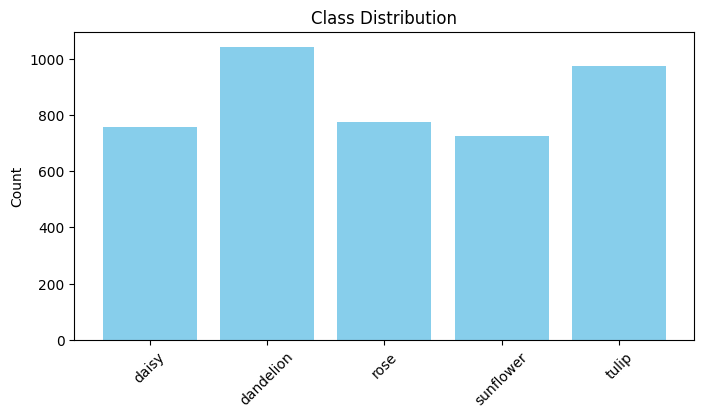

In [8]:
# Distribution of images in Train folder
class_counts = {}
for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

total_images = sum(class_counts.values())
print(f"Total images: {total_images}\n")
print(f"Class distribution: {class_counts}\n")

# Plot Training Distribution
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xticks(rotation=45)
plt.title('Class Distribution')
plt.ylabel('Count')
plt.show()


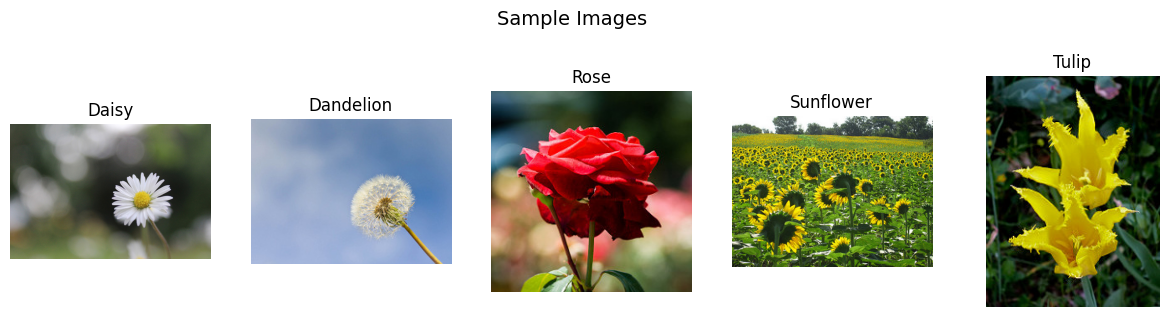

In [9]:
# Visualize sample images
plt.figure(figsize=(15, 3))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    sample_img = os.path.join(cls_path, os.listdir(cls_path)[0])
    img = Image.open(sample_img)
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(cls.capitalize())
    plt.axis('off')
plt.suptitle("Sample Images", y=1.1, fontsize=14)
plt.show()


### Data Preprocessing & Validation Split

**Justification for Preprocessing Choices:**
- **Why 128x128?** Images were resized to 128x128 to reduce computational cost and memory usage while preserving sufficient visual features.
- **Why 20% Validation?** A validation split of 20% was used to ensure sufficient data for training while maintaining a reliable evaluation set.
- **Why Augmentation?** Data augmentation was applied to improve generalization and reduce overfitting by introducing variability in training samples.


In [10]:
#data generators


IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Training generator (WITH augmentation)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation generator (NO augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Train generator
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True
)

# Validation generator
val_gen = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)


# CLASS WEIGHTS

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Found 3423 images belonging to 5 classes.
Found 854 images belonging to 5 classes.
Class Weights: {0: np.float64(1.1315702479338843), 1: np.float64(0.8188995215311005), 2: np.float64(1.1024154589371982), 3: np.float64(1.180344827586207), 4: np.float64(0.8765685019206146)}


In [11]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# IMPROVED CALLBACKS to prevent early restoration of collapsed weights
callbacks_base= [
    EarlyStopping(
        monitor='val_accuracy',  # Monitor accuracy to ensure predictive power
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [12]:
#IMPROVED CALLBACKS to prevent early restoration of collapsed weights
callbacks_deep= [
    EarlyStopping(
        monitor='val_accuracy',  # Monitor accuracy to ensure predictive power
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

In [13]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_baseline_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks_base.append(checkpoint)

In [14]:
# Dataset split info
print("Train samples:", train_gen.samples)
print("Validation samples:", val_gen.samples)

# Class label mapping
print("Class Indices:", train_gen.class_indices)

# Class distribution percentage
print("\nClass Distribution (%):")
for cls, count in class_counts.items():
    print(f"{cls}: {count} ({count/total_images*100:.2f}%)")

Train samples: 3423
Validation samples: 854
Class Indices: {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}

Class Distribution (%):
daisy: 756 (17.68%)
dandelion: 1044 (24.41%)
rose: 776 (18.14%)
sunflower: 725 (16.95%)
tulip: 976 (22.82%)


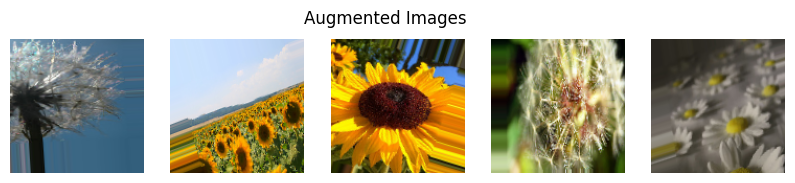

In [15]:
# Visualize augmented images
x, _ = next(train_gen)

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x[i])
    plt.axis('off')
plt.suptitle("Augmented Images")
plt.show()


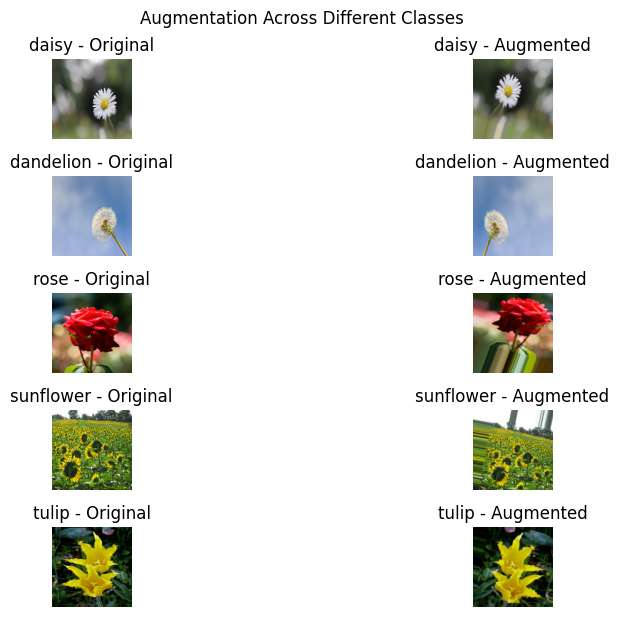

In [16]:
plt.figure(figsize=(12, 6))

num_classes_to_show = min(5, len(classes))

for i, cls in enumerate(classes[:num_classes_to_show]):
    cls_path = os.path.join(train_dir, cls)
    img_path = os.path.join(cls_path, os.listdir(cls_path)[0])

    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img) / 255.0

    # Original
    plt.subplot(num_classes_to_show, 2, 2*i + 1)
    plt.imshow(img_array)
    plt.title(f"{cls} - Original")
    plt.axis('off')

    # Augmented
    augmented = train_datagen.random_transform(img_array)
    plt.subplot(num_classes_to_show, 2, 2*i + 2)
    plt.imshow(augmented)
    plt.title(f"{cls} - Augmented")
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Augmentation Across Different Classes", y=1.02)
plt.show()

## 2.5.2 Design, Train, and Evaluate a Baseline Model
- 3 Convolutional layers + Pooling
- 3 Fully Connected layers


In [17]:
def build_baseline():
    model = models.Sequential([
        # Input Layer
        layers.Input(shape=(128, 128, 3)),

        # 3 Conv + Pool layers
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # use flatten in baseline model
        layers.Flatten(),

        # 3 Fully Connected layers
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),

        # Output
        layers.Dense(5, activation='softmax')
    ])
    return model

baseline_model = build_baseline()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,315,141 (12.65 MB)

 Trainable params: 3,315,141 (12.65 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train Baseline
epochs = 50

start_time = time.time()
history_base = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks_base,
    class_weight=class_weights
)
elapsed = time.time() - start_time
print(f"\nTraining time (Baseline): {elapsed/60:.1f} minutes")


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.3274 - loss: 1.4059
Epoch 1: val_accuracy improved from None to 0.48478, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 1: val_accuracy improved from None to 0.48478, saving model to best_baseline_model.keras

Epoch 1: finished saving model to best_baseline_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 374ms/step - accuracy: 0.4090 - loss: 1.2694 - val_accuracy: 0.4848 - val_loss: 1.1904 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5445 - loss: 1.0663
Epoch 2: val_accuracy improved from 0.48478 to 0.59602, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.48478 to 0.59602, saving model to best_baseline_model.keras

Epoch 2: finished saving model to best_baseline_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 320ms/step - accuracy: 0.5662 - loss: 1.0460 - val_

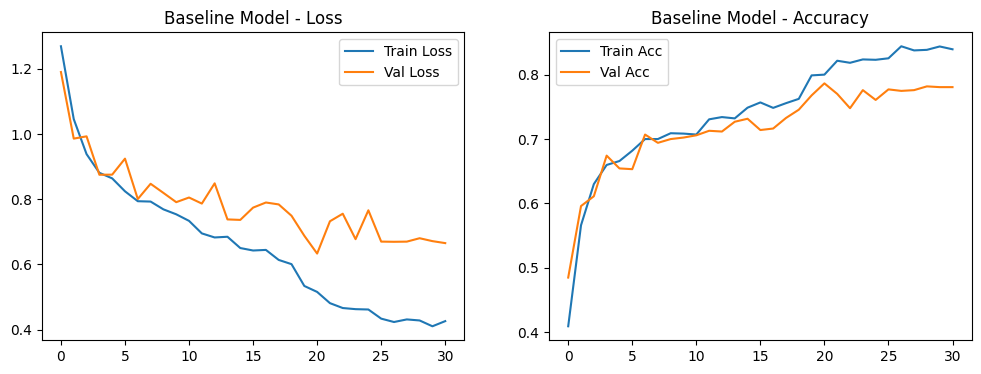

In [19]:
# Plot Training vs Validation Curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train Acc')
    ax2.plot(history.history['val_accuracy'], label='Val Acc')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()
    plt.show()

plot_history(history_base, "Baseline Model")


27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 147ms/step - accuracy: 0.7869 - loss: 0.6333
Baseline Validation Accuracy: 0.7869
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step

Classification Report:
              precision    recall  f1-score   support

       daisy       0.85      0.81      0.83       151
   dandelion       0.92      0.74      0.82       208
        rose       0.66      0.81      0.73       155
   sunflower       0.71      0.88      0.78       145
       tulip       0.83      0.74      0.78       195

    accuracy                           0.79       854
   macro avg       0.79      0.79      0.79       854
weighted avg       0.80      0.79      0.79       854



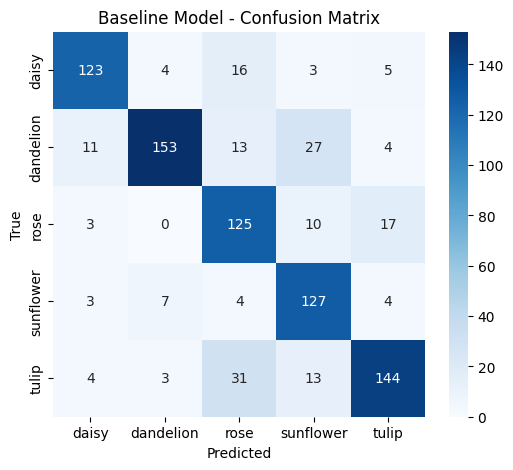

In [20]:
# Evaluate using the Validation Set
val_gen.reset() # Reseting generator before evaluation
val_loss, val_acc = baseline_model.evaluate(val_gen)
print(f"Baseline Validation Accuracy: {val_acc:.4f}")

val_gen.reset()
y_pred = np.argmax(baseline_model.predict(val_gen), axis=1)
y_true = val_gen.classes

# Confusion Matrix and Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Baseline Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

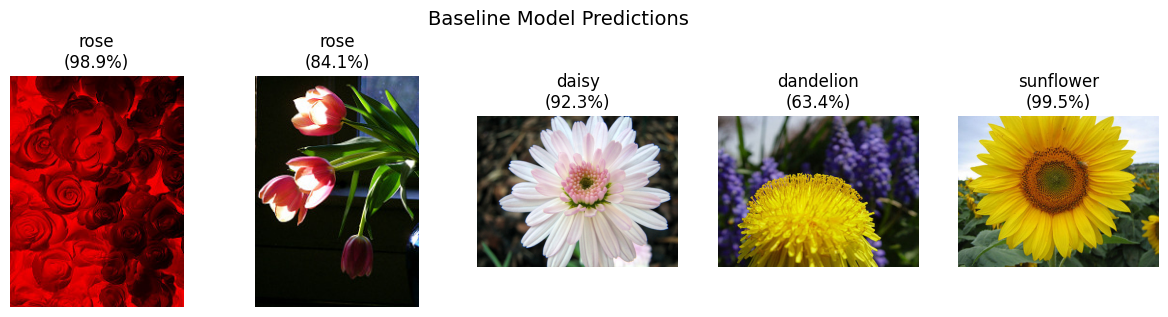

In [21]:
plt.figure(figsize=(15, 3))

test_images = sorted(os.listdir(test_dir))

for i, img_name in enumerate(test_images):

    img_path = os.path.join(test_dir, img_name)

    # Load image
    img = load_img(img_path, target_size=IMG_SIZE)

    # Convert to array
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = baseline_model.predict(img_array, verbose=0)

    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    # Display
    plt.subplot(1, len(test_images), i + 1)
    plt.imshow(load_img(img_path))
    plt.title(f"{predicted_class}\n({confidence:.1f}%)")
    plt.axis('off')

plt.suptitle("Baseline Model Predictions", y=1.1, fontsize=14)
plt.show()

## 2.5.3 Deeper Architecture with Regularization Layer
Adding more filters, `BatchNormalization`, and `Dropout` to reduce overfitting. We place BatchNormalization appropriately and use moderate dropout rates.


In [22]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_deeper_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

callbacks_deep.append(checkpoint)

In [23]:
def build_deeper():
    model = models.Sequential([
        # Input layer (fix warning)
        layers.Input(shape=(128, 128, 3)),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # Block 4
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # Block 5
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # Feature aggregation
        layers.GlobalAveragePooling2D(),

        # Fully connected (cleaner + effective)
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),

        # Output
        layers.Dense(5, activation='softmax')
    ])
    return model

deeper_model = build_deeper()
deeper_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        65,79

 Total params: 1,088,709 (4.15 MB)

 Trainable params: 1,087,237 (4.15 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.3992 - loss: 1.3887
Epoch 1: val_accuracy improved from None to 0.25761, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras

Epoch 1: val_accuracy improved from None to 0.25761, saving model to best_deeper_model.keras

Epoch 1: finished saving model to best_deeper_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 412ms/step - accuracy: 0.4566 - loss: 1.2813 - val_accuracy: 0.2576 - val_loss: 1.8963 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.5431 - loss: 1.0791
Epoch 2: val_accuracy improved from 0.25761 to 0.26347, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras

Epoch 2: val_accuracy improved from 0.25761 to 0.26347, saving model to best_deeper_model.keras

Epoch 2: finished saving model to best_deeper_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 319ms/step - accuracy: 0.5516 - loss: 1.0636 - val_accuracy

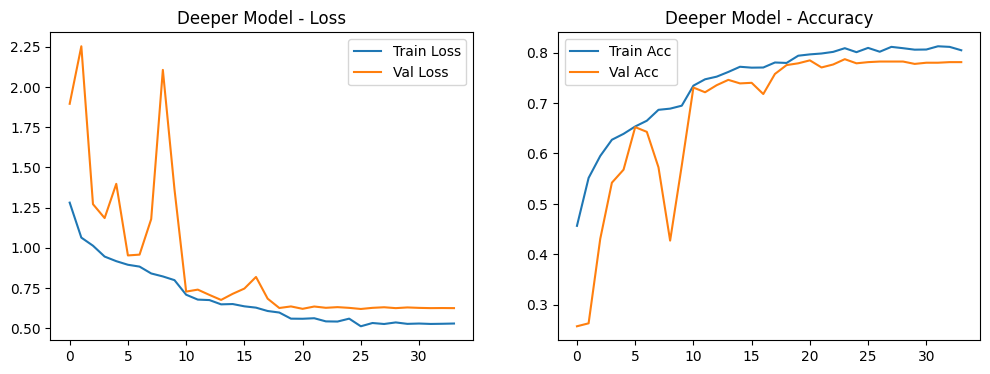

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.7869 - loss: 0.6311
Deeper Model Validation Accuracy: 0.7869
27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step


In [24]:
deeper_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

start_time = time.time()
history_deep = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks_deep,
    class_weight=class_weights
)
elapsed = time.time() - start_time
print(f"\nTraining time (Deeper Model - Adam): {elapsed/60:.1f} minutes")

plot_history(history_deep, "Deeper Model")

val_gen.reset()
val_loss_deep, val_acc_deep = deeper_model.evaluate(val_gen)
print(f"Deeper Model Validation Accuracy: {val_acc_deep:.4f}")

val_gen.reset()
y_pred_probs = deeper_model.predict(val_gen)
y_pred_deep = np.argmax(y_pred_probs, axis=1)
y_true = val_gen.classes



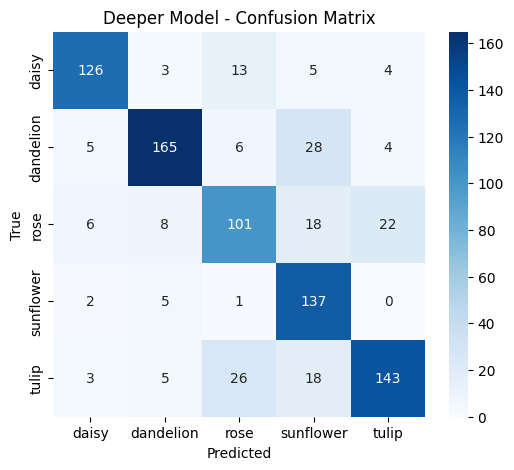

In [25]:
# Confusion Matrix
cm_deep = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Deeper Model - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()



In [26]:
# Classification Report
print("\nClassification Report (Deeper - Adam):")
print(classification_report(y_true, y_pred_deep, target_names=classes))


Classification Report (Deeper - Adam):
              precision    recall  f1-score   support

       daisy       0.89      0.83      0.86       151
   dandelion       0.89      0.79      0.84       208
        rose       0.69      0.65      0.67       155
   sunflower       0.67      0.94      0.78       145
       tulip       0.83      0.73      0.78       195

    accuracy                           0.79       854
   macro avg       0.79      0.79      0.78       854
weighted avg       0.80      0.79      0.79       854



## 2.5.4 Experimentation and Comparative Analysis
* **Baseline vs Deeper Model**: The Deeper model typically generalizes better and reduces overfitting on the training set due to Dropout and Batch Normalization.
* **Optimizer Analysis**: Below, we will try the SGD optimizer (with momentum) on the deeper model to compare with Adam.


In [27]:
#IMPROVED CALLBACKS to prevent early restoration of collapsed weights
callbacks_sgd= [
    EarlyStopping(
        monitor='val_accuracy',  # Monitor accuracy to ensure predictive power
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_deeper_sgd_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

Training Deeper Model with SGD optimizer...
Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.3224 - loss: 1.6968
Epoch 1: val_accuracy improved from None to 0.24356, saving model to best_deeper_sgd_model.keras

Epoch 1: finished saving model to best_deeper_sgd_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 368ms/step - accuracy: 0.3964 - loss: 1.4341 - val_accuracy: 0.2436 - val_loss: 1.7074 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.4993 - loss: 1.2040
Epoch 2: val_accuracy did not improve from 0.24356
107/107 ━━━━━━━━━━━━━━━━━━━━ 34s 316ms/step - accuracy: 0.5110 - loss: 1.1848 - val_accuracy: 0.2436 - val_loss: 2.0097 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.5720 - loss: 1.0842
Epoch 3: val_accuracy improved from 0.24356 to 0.30445, saving model to best_deeper_sgd_model.keras

Epoch 3: finished saving model to best_deeper_sgd_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3

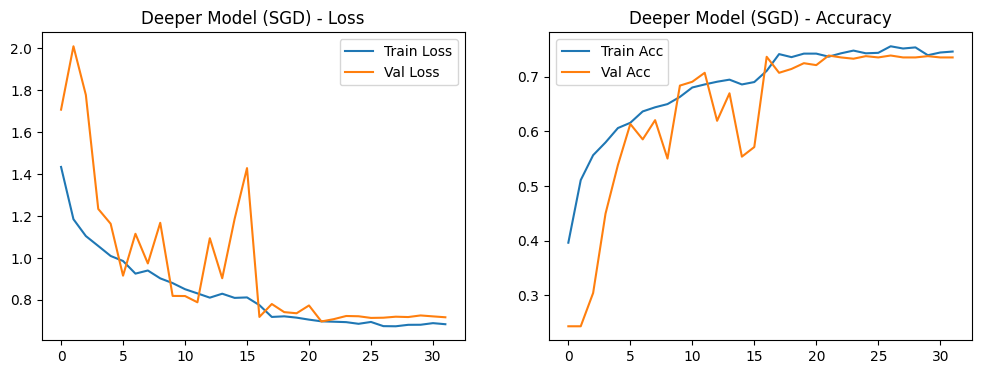

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.7389 - loss: 0.6970
Deeper Model (SGD) Validation Accuracy: 0.7389


In [28]:
from tensorflow.keras.optimizers import SGD

deeper_model_sgd = build_deeper()
# Adding momentum and adjusting learning rate to stabilize SGD with BatchNorm
deeper_model_sgd.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9), loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Deeper Model with SGD optimizer...")
start_time = time.time()
history_sgd = deeper_model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks_sgd
)
elapsed = time.time() - start_time
print(f"\nTraining time (Deeper Model - SGD): {elapsed/60:.1f} minutes")

plot_history(history_sgd, "Deeper Model (SGD)")

val_loss_sgd, val_acc_sgd = deeper_model_sgd.evaluate(val_gen)
print(f"Deeper Model (SGD) Validation Accuracy: {val_acc_sgd:.4f}")


val_gen.reset()



## 2.5.5 Ablation Study
* **Removing Dropout**: We train the deeper model but without dropout layers to see its effect on overfitting. Removing dropout will likely increase training accuracy quickly but validation accuracy might plateau or drop.


Training Ablation Model (No Dropout)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.4637 - loss: 1.2716
Epoch 1: val_accuracy improved from None to 0.24356, saving model to best_ablation_model.keras

Epoch 1: finished saving model to best_ablation_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 369ms/step - accuracy: 0.5057 - loss: 1.1707 - val_accuracy: 0.2436 - val_loss: 3.5534 - learning_rate: 0.0010
Epoch 2/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.5941 - loss: 0.9940
Epoch 2: val_accuracy improved from 0.24356 to 0.27400, saving model to best_ablation_model.keras

Epoch 2: finished saving model to best_ablation_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 33s 312ms/step - accuracy: 0.6109 - loss: 0.9693 - val_accuracy: 0.2740 - val_loss: 2.4464 - learning_rate: 0.0010
Epoch 3/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.6379 - loss: 0.9140
Epoch 3: val_accuracy improved from 0.27400 to 0.38876, saving model to best_ablation_model.keras

Epoch 3: finished saving model to 

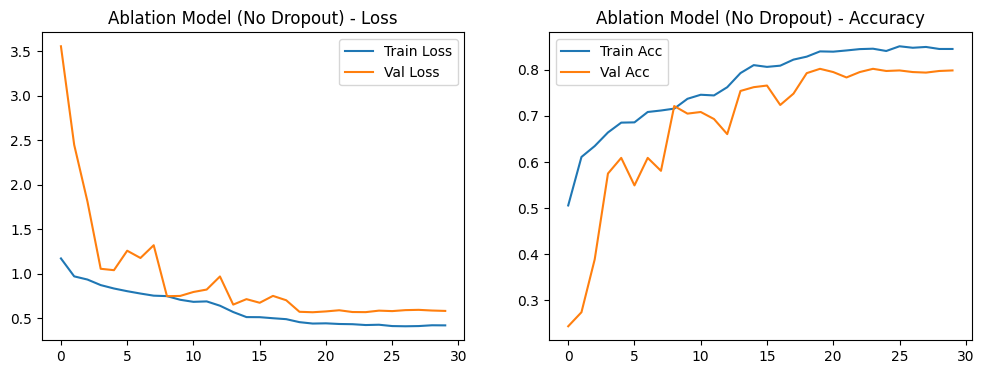

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - accuracy: 0.8021 - loss: 0.5664
Ablation Model Validation Accuracy: 0.8021


In [29]:
def build_ablation():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(128, 128, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D(2, 2),

        # SAME as deeper model
        layers.GlobalAveragePooling2D(),


        layers.Dense(256, activation='relu'),
        # No Dropout
        layers.Dense(128, activation='relu'),
        # No Dropout
        layers.Dense(64, activation='relu'),
        # No Dropout
        layers.Dense(5, activation='softmax')
    ])
    return model



callbacks_ablation= [
    EarlyStopping(
        monitor='val_accuracy',  # Monitor accuracy to ensure predictive power
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),

    ModelCheckpoint(
        "best_ablation_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

ablation_model = build_ablation()
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Ablation Model (No Dropout)...")
start_time = time.time()
history_ablation = ablation_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=callbacks_ablation
)
elapsed = time.time() - start_time
print(f"\nTraining time (Ablation - No Dropout): {elapsed/60:.1f} minutes")

plot_history(history_ablation, "Ablation Model (No Dropout)")

val_loss_abl, val_acc_abl = ablation_model.evaluate(val_gen)
print(f"Ablation Model Validation Accuracy: {val_acc_abl:.4f}")


## 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)
Using the highly efficient `MobileNetV2` trained on ImageNet. We will first extract features by freezing the base layers, and then fine-tune some layers.

*(Note: We resize images to 224x224, as expected by MobileNetV2)*


In [30]:
# Re-initialize Data Generators with 224x224 Target Size


from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE_TL = (224, 224)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_gen_tl = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
    shuffle=True
)

val_gen_tl = val_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

Found 3423 images belonging to 5 classes.
Found 854 images belonging to 5 classes.


In [31]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # Feature extraction phase

tl_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
tl_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
callbacks_tl = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_tl_feature_extractor.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

Training Transfer Learning Model (Feature Extraction)...
Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 632ms/step - accuracy: 0.6070 - loss: 1.0190
Epoch 1: val_accuracy improved from None to 0.86066, saving model to best_tl_feature_extractor.keras

Epoch 1: finished saving model to best_tl_feature_extractor.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 107s 826ms/step - accuracy: 0.7239 - loss: 0.7262 - val_accuracy: 0.8607 - val_loss: 0.3949 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8206 - loss: 0.4796
Epoch 2: val_accuracy improved from 0.86066 to 0.88290, saving model to best_tl_feature_extractor.keras

Epoch 2: finished saving model to best_tl_feature_extractor.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 62s 580ms/step - accuracy: 0.8349 - loss: 0.4435 - val_accuracy: 0.8829 - val_loss: 0.3449 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.8601 - loss: 0.3713
Epoch 3: val_accuracy did not improve from 0.88290


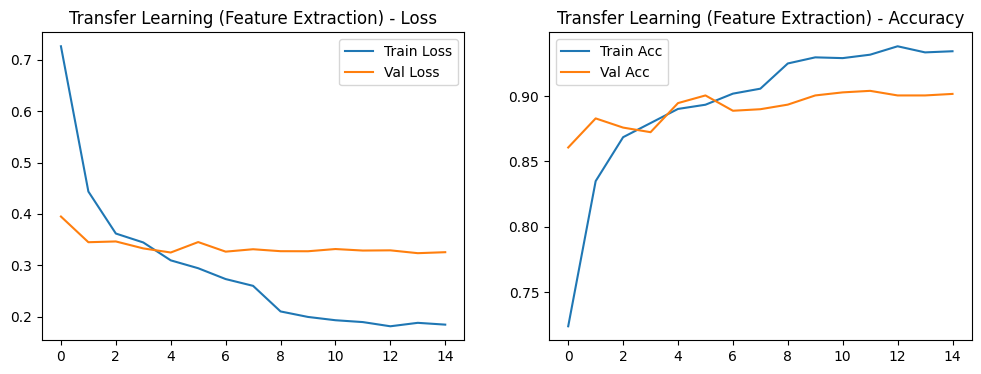

27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.9040 - loss: 0.3286
Transfer Learning (Feature Extraction) Validation Accuracy: 0.9040


In [34]:
# Train Transfer Learning model (Feature Extraction)
print("Training Transfer Learning Model (Feature Extraction)...")
start_time = time.time()
history_tl = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=15, # Shorter phase 1
    callbacks=callbacks_tl
)
elapsed = time.time() - start_time
print(f"\nTraining time (TL - Feature Extraction): {elapsed/60:.1f} minutes")

plot_history(history_tl, "Transfer Learning (Feature Extraction)")

val_loss_tl, val_acc_tl = tl_model.evaluate(val_gen_tl)
print(f"Transfer Learning (Feature Extraction) Validation Accuracy: {val_acc_tl:.4f}")


### Fine-Tuning MobileNetV2
After the model has learned the initial patterns with the frozen base, we unfreeze the last 30 layers and train with a very low learning rate to fine-tune the representations.


Fine-tuning Transfer Learning Model...
Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.8422 - loss: 0.4421
Epoch 1: val_accuracy improved from None to 0.90164, saving model to best_tl_finetuned.keras

Epoch 1: finished saving model to best_tl_finetuned.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 96s 737ms/step - accuracy: 0.8557 - loss: 0.3975 - val_accuracy: 0.9016 - val_loss: 0.3299 - learning_rate: 1.0000e-05
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8625 - loss: 0.3644
Epoch 2: val_accuracy did not improve from 0.90164
107/107 ━━━━━━━━━━━━━━━━━━━━ 61s 569ms/step - accuracy: 0.8753 - loss: 0.3378 - val_accuracy: 0.8958 - val_loss: 0.3389 - learning_rate: 1.0000e-05
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 528ms/step - accuracy: 0.8970 - loss: 0.2864
Epoch 3: val_accuracy did not improve from 0.90164
107/107 ━━━━━━━━━━━━━━━━━━━━ 61s 569ms/step - accuracy: 0.8940 - loss: 0.2932 - val_accuracy: 0.8958 - val_loss: 0.3260 - learning_rate: 1.0000e-05

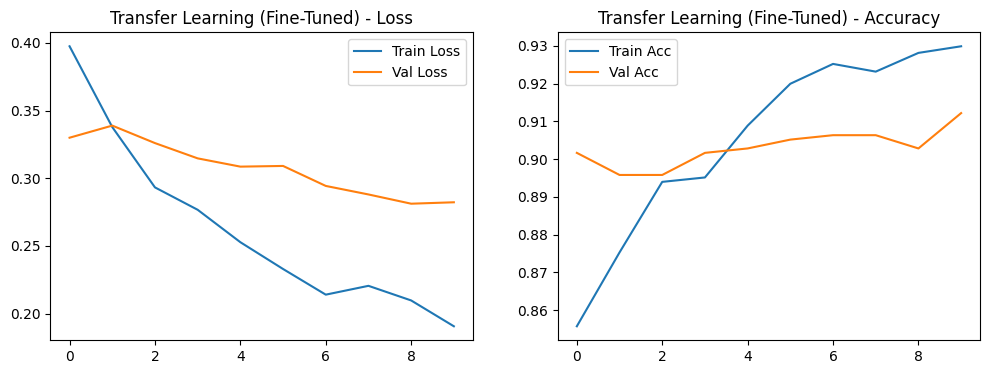

27/27 ━━━━━━━━━━━━━━━━━━━━ 5s 171ms/step - accuracy: 0.9122 - loss: 0.2822
Fine-tuned TL Accuracy: 0.9122
27/27 ━━━━━━━━━━━━━━━━━━━━ 15s 355ms/step

Classification Report (Fine-Tuned TL):
              precision    recall  f1-score   support

       daisy       0.89      0.93      0.91       151
   dandelion       0.94      0.90      0.92       208
        rose       0.94      0.88      0.91       155
   sunflower       0.87      0.94      0.91       145
       tulip       0.91      0.91      0.91       195

    accuracy                           0.91       854
   macro avg       0.91      0.91      0.91       854
weighted avg       0.91      0.91      0.91       854



In [35]:
# Phase 2: Fine-tuning
base_model.trainable = True

# Freeze all except last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


callbacks_tl_ft = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        "best_tl_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode='max',
        verbose=1
    )
]


print("Fine-tuning Transfer Learning Model...")

start_time = time.time()

history_tl_finetune = tl_model.fit(
    train_gen_tl,
    validation_data=val_gen_tl,
    epochs=10,
    callbacks=callbacks_tl_ft
)

print(f"Fine-tuning time: {(time.time() - start_time)/60:.2f} minutes")

plot_history(history_tl_finetune, "Transfer Learning (Fine-Tuned)")

val_loss_tl_ft, val_acc_tl_ft = tl_model.evaluate(val_gen_tl)
print(f"Fine-tuned TL Accuracy: {val_acc_tl_ft:.4f}")

# Classification report for final best model
val_gen_tl.reset()
y_pred_tl = np.argmax(tl_model.predict(val_gen_tl), axis=1)
y_true_tl = val_gen_tl.classes

print("\nClassification Report (Fine-Tuned TL):")
print(classification_report(y_true_tl, y_pred_tl, target_names=classes))


### Qualitative Inference on Test Set
Let's use our best model (Transfer Learning) to predict the 5 unlabelled images in the `Test` folder.


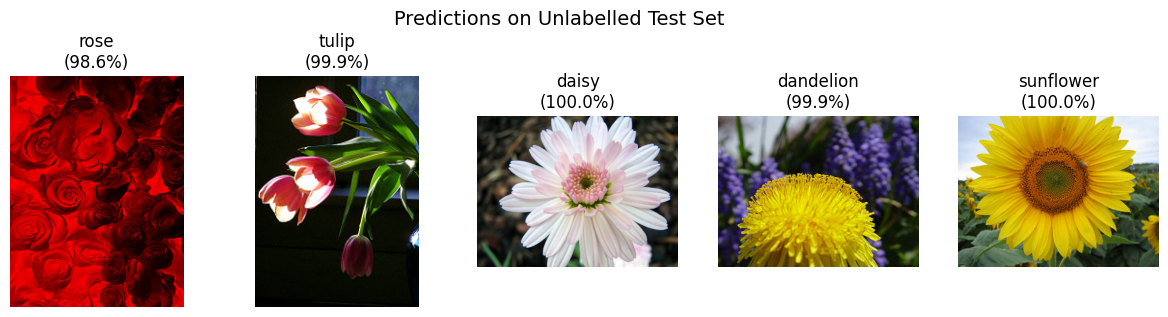

In [36]:
plt.figure(figsize=(15, 3))

test_images = sorted(os.listdir(test_dir))

for i, img_name in enumerate(test_images):
    img_path = os.path.join(test_dir, img_name)

    img = load_img(img_path, target_size=IMG_SIZE_TL)
    img_array = img_to_array(img)

    # FIXED preprocessing for MobileNetV2
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    prediction = tl_model.predict(img_array, verbose=0)
    predicted_class = classes[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    plt.subplot(1, len(test_images), i + 1)
    plt.imshow(load_img(img_path))
    plt.title(f"{predicted_class}\n({confidence:.1f}%)")
    plt.axis('off')

plt.suptitle("Predictions on Unlabelled Test Set", y=1.1, fontsize=14)
plt.show()
